In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris=load_iris()
X=iris.data[:,(2,3)]
y=(iris.target==0).astype(int)

In [2]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [3]:
per_clf = Perceptron()
per_clf.fit(X,y)
y_pred = per_clf.predict([[2,0.5]])

The hyperbolic tangent function tanh(z) = 2σ(2z) – 1

The Rectified Linear Unit function: ReLU(z) = max(0, z)

Regression MLPs

The Huber loss is quadratic when the error is smaller than a thres‐
hold δ (typically 1), but linear when the error is larger than δ. This
makes it less sensitive to outliers than the mean squared error, and
it is often more precise and converges faster than the mean abso‐
lute error

In [4]:
import tensorflow as tf
from tensorflow import keras 
tf.__version__

'2.21.0'

In [5]:
keras.__version__

'3.14.0'

Building a Image Classifier using the Sequential API

In [6]:
fashion_mnist = keras.datasets.fashion_mnist 
(X_train_full,y_train_full),(X_test,y_test) = fashion_mnist.load_data()

In [7]:
X_train_full.shape

(60000, 28, 28)

In [8]:
X_test.dtype

dtype('uint8')

In [9]:
X_valid,X_train = X_train_full[:5000]/255.0, X_train_full[5000:]/255.0
y_valid,y_train= y_train_full[:5000],y_train_full[5000:]

In [10]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


OR

In [11]:
model = keras.models.Sequential(
    [
        keras.layers.Flatten(input_shape=[28,28]),
        keras.layers.Dense(300,activation='relu'),
        keras.layers.Dense(100,activation='relu'),
        keras.layers.Dense(10,activation='softmax')
    ]
)

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
hidden1 = model.layers[1]
weights,biases = hidden1.get_weights()


In [14]:
weights.shape, biases.shape

((784, 300), (300,))

In [15]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer = 'sgd',
              metrics=['accuracy'])

Training and Evaluating the model

In [16]:
history = model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7635 - loss: 0.7189 - val_accuracy: 0.8228 - val_loss: 0.5122
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8299 - loss: 0.4918 - val_accuracy: 0.8358 - val_loss: 0.4623
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8443 - loss: 0.4467 - val_accuracy: 0.8208 - val_loss: 0.5033
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8542 - loss: 0.4192 - val_accuracy: 0.8574 - val_loss: 0.4005
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8609 - loss: 0.3987 - val_accuracy: 0.8584 - val_loss: 0.4063
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8650 - loss: 0.3820 - val_accuracy: 0.8674 - val_loss: 0.3829
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8697 - loss: 0.3680 - val_accuracy: 0.8642 - val_loss: 0.3887
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8737 - loss: 0.3571 - 

In [17]:
tf.config.list_physical_devices('GPU')

[]

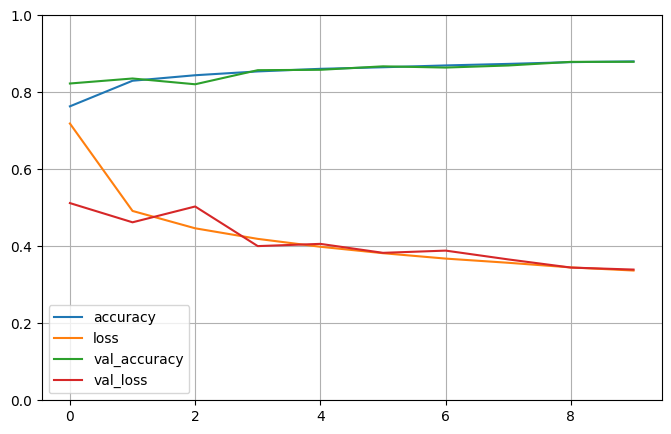

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()


In [19]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8187 - loss: 70.2570


[70.25703430175781, 0.8187000155448914]

Using the Model to make Predictions

In [20]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [21]:
y_pred = np.argmax(y_proba,axis=1)
y_pred

array([9, 2, 1])

In [22]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

Building a Regression MLP Using the Sequential API

In [23]:
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,y
)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = keras.Sequential([
    keras.layers.Dense(30,activation='relu',input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss='mean_squared_error',optimizer='sgd')
history = model.fit(X_train, y_train, epochs=10,
                    validation_data = (X_valid,y_valid))

mse_test = model.evaluate(X_test,y_test)
X_new = X[:3]
y_pred = model.predict(X_new)

Epoch 1/10


c:\Users\91911\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf       
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: inf - val_loss: 5685689002652369505514016380813312.0000
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 395736044864101596285961328656384.0000 - val_loss: 2426126405898866685238050816.0000
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 168863708860026080639057920.0000 - val_loss: 1035250749855468879872.0000
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 72055500567788650496.0000 - val_loss: 441749063335936.0000
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30746630684672.0000 - val_loss: 188499360.0000
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13119918.0000 - val_loss: 81.3409
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9047 - val_loss: 1.3337
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3379 - val_loss: 1.3336
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━

Building Complex Models Using the Functional API

In [25]:
input = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30,activation='relu')(input)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input,hidden2])
output  = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input],outputs=[output])

In [26]:
input_A = keras.layers.Input(shape=[5])
input_B = keras.layers.Input(shape=[6])
hidden1 = keras.layers.Dense(30,activation='relu')(input_B)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A,hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_A,input_B], outputs=[output])

In [27]:
model.compile(loss = 'mse' , optimizer='sgd')
X_train_A, X_train_B = X_train[:,:5], X_train[:,2:]
X_valid_A, X_valid_B = X_valid[:,:5], X_valid[:,2:]
X_test_A, X_test_B = X_test[:,:5], X_test[:,2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

history = model.fit((X_train_A,X_train_B),y_train, epochs=10,
                    validation_data=((X_valid_A, X_valid_B),y_valid))
mse = model.evaluate((X_test_A,X_test_B), y_test)
y_pred = model.predict((X_new_A,X_new_B))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [28]:
input_A = keras.layers.Input(shape=[5])
input_B = keras.layers.Input(shape=[6])
hidden1 = keras.layers.Dense(30,activation='relu')(input_B)
hidden2 = keras.layers.Dense(30,activation='relu')(hidden1)
concat = keras.layers.concatenate([input_A,hidden2])
output = keras.layers.Dense(1)(concat)
aux_output = keras.layers.Dense(1)(hidden2)
model = keras.models.Model(inputs=[input_A,input_B], outputs=[output,aux_output])

In [29]:
model.compile(loss=['mse','mse'],loss_weights=[0.9,0.1],optimizer='sgd')

In [30]:
history = model.fit(
    [X_train_A,X_train_B],[y_train,y_train],epochs=10,
    validation_data=([X_valid_A,X_valid_B],[y_valid,y_valid])
)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_dense_17_loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan - val_dense_16_loss: nan - val_den

In [31]:
total_loss, main_loss, aux_loss = model.evaluate([X_test_A,X_test_B],[y_test,y_test])

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan


In [32]:
y_pred_main, y_pred_aux = model.predict([X_new_A,X_new_B])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


Building Dynamic Models Using the Subclassing API

In [38]:
class WideAndDeepModel(keras.models.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        
        self.concat = keras.layers.Concatenate()   
        
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        
        concat = self.concat([input_A, hidden2])  
        
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        
        return main_output, aux_output

In [39]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 30)        │        210 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 30)        │        930 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 35)        │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         36 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         31 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,209 (4.73 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Saving and Restoring a Model

In [40]:
model.save('my_keras_model.h5')

Loading

Using CallBacks<br> saving the model at checkpoints useful when training the model takes long time

The fit() method accepts a callbacks argument that lets you specify a list of objects
that Keras will call during training at the start and end of training, at the start and end
of each epoch and even before and after processing each batch. For example, the ModelCheckpoint callback saves checkpoints of your model at regular intervals during
training, by default at the end of each epoch:


In [41]:
model.compile(loss=['mse','mse'],optimizer='sgd')

In [42]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5")
history = model.fit((X_train_A,X_train_B),(y_train,y_train),epochs=10,callbacks=[checkpoint_cb])

Epoch 1/10


357/363 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 2/10
337/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 3/10
317/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 4/10
356/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan  

...

363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan  
Epoch 7/10
345/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 8/10
332/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
Epoch 9/10
319/363 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan  
Epoch 10/10
337/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_16_loss: nan - dense_17_loss: nan - loss: nan
